# AlignOT Iterative Subtomogram Averaging

This notebook performs iterative rotational alignment and subtomogram averaging on the 200 subtomograms in `Data/0.1/Cluster_0`.

Workflow summary:
- compute the initial reference as the plain average of the original subtomograms
- estimate per-subtomogram rotations with AlignOT on sampled point clouds
- rotate the full original subtomogram volume with ASPiRE
- average the rotated volumes to form the next-round reference

Important rule:
- every round always reloads and aligns the original subtomogram files
- no previously rotated subtomogram is reused as the next round's alignment input


In [1]:
%matplotlib inline

from utils import *

import contextlib
import gc
import io
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import pandas as pd
from aspire.utils.rotation import Rotation
from aspire.volume import Volume

plt.rcParams["figure.figsize"] = (7, 5)
plt.style.use("default")


/home/anshu/subtmgr-align/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1*q0^1 + (-1*q1^1)i + (-1*q2^1)j + (-1*q3^1)k
1*q0^1 + (1*q1^1)i + (1*q2^1)j + (1*q3^1)k
0*q0^1q3^1 + 0*q1^1q3^1 + 0*q2^1q3^1 + (1*q1^2 + 2*q1^1q2^1 + 2*q1^1q3^1 + 1*q0^2 + 2*q0^1q2^1 + -2*q0^1q3^1 + -1*q3^2 + -1*q2^2)i + (2*q1^1q2^1 + 1*q2^2 + 2*q2^1q3^1 + 1*q0^2 + 2*q0^1q3^1 + -2*q0^1q1^1 + -1*q1^2 + -1*q3^2)j + (2*q1^1q3^1 + 2*q2^1q3^1 + 1*q3^2 + 1*q0^2 + 2*q0^1q1^1 + -2*q0^1q2^1 + -1*q2^2 + -1*q1^2)k


In [13]:
cluster_dir = Path("Data/0.1/Cluster_0")
output_dir = Path("iterative_alignment_outputs_cluster0")

n_subtomograms = 200
n_rounds = 5
threshold = 0.7
num_points = 500
max_iter = 200
lr = 1e-5
reg = 30
num_samples = 1
experiment_seed = 11
cleanup_every = 10
progress_every = 10

output_dir.mkdir(parents=True, exist_ok=True)
cluster_dir, output_dir


(PosixPath('Data/0.1/Cluster_0'),
 PosixPath('iterative_alignment_outputs_cluster0'))

In [4]:
def get_cluster_paths(cluster_dir, n_expected=200):
    cluster_dir = Path(cluster_dir)
    paths = [path for path in cluster_dir.iterdir() if path.is_file() and path.suffix == ".mrc"]
    paths = sorted(paths, key=lambda path: int(path.stem))
    if n_expected is not None and len(paths) != n_expected:
        raise ValueError(f"Expected {n_expected} .mrc files, found {len(paths)} in {cluster_dir}")
    return paths


def load_mrc(path, permissive=False):
    with mrcfile.open(path, permissive=permissive) as mrc:
        return np.array(mrc.data, dtype=np.float32)


def save_mrc(path, arr):
    arr = np.asarray(arr, dtype=np.float32)
    with mrcfile.new(path, overwrite=True) as mrc:
        mrc.set_data(arr)
    return Path(path)


def normalize_volume(volume):
    volume = np.asarray(volume, dtype=np.float32)
    volume = volume - volume.min()
    vmax = float(volume.max())
    if vmax <= 0:
        raise ValueError("Volume became constant after shifting to non-negative values.")
    return volume / (vmax + 1e-8)


def prepare_sampling_volume(volume):
    norm = normalize_volume(volume)
    return 1.0 - norm


def sample_volume_in_memory(prepared_volume, threshold, num_points, random_seed=None):
    map_th = np.asarray(prepared_volume, dtype=np.float32).copy()
    map_th[map_th < threshold] = 0
    if float(map_th.sum()) <= 0:
        raise ValueError(f"Threshold {threshold} removes all density from the prepared sampling volume.")

    with contextlib.redirect_stdout(io.StringIO()):
        rm0, arr_flat, arr_idx, xyz, coords_1d = trn.trn_rm0(
            map_th,
            M=num_points,
            random_seed=random_seed,
        )
        rms, rs, ts_save = trn.trn_iterate(
            rm0,
            arr_flat,
            arr_idx,
            xyz,
            n_save=10,
            e0=0.3,
            ef=0.05,
            l0=0.005 * num_points,
            lf=0.5,
            tf=num_points * 8,
            do_log=True,
            log_n=10,
        )

    points = rms[-1]
    return points[:, 0].tolist(), points[:, 1].tolist(), points[:, 2].tolist()


def quaternion_to_rotation_matrix(q):
    q = np.asarray(q, dtype=np.float32)
    q = q / np.linalg.norm(q)
    a, b, c, d = q
    return np.array([
        [a * a + b * b - c * c - d * d, 2 * b * c - 2 * a * d, 2 * b * d + 2 * a * c],
        [2 * b * c + 2 * a * d, a * a - b * b + c * c - d * d, 2 * c * d - 2 * a * b],
        [2 * b * d - 2 * a * c, 2 * c * d + 2 * a * b, a * a - b * b - c * c + d * d],
    ], dtype=np.float32)


def rotate_volume_with_quaternion(volume, q):
    rotation_matrix = quaternion_to_rotation_matrix(q)
    rotated = Volume(np.asarray(volume, dtype=np.float32)).rotate(Rotation(rotation_matrix))._data[0]
    return np.asarray(rotated, dtype=np.float32)


def compute_streaming_average(paths, progress_every=20):
    total = None
    count = 0
    for idx, path in enumerate(paths, start=1):
        arr = load_mrc(path, permissive=False)
        if total is None:
            total = np.zeros_like(arr, dtype=np.float64)
        total += arr
        count += 1
        if progress_every and (idx % progress_every == 0 or idx == len(paths)):
            print(f"Initial averaging: loaded {idx}/{len(paths)} subtomograms")
        del arr
        if progress_every and idx % progress_every == 0:
            gc.collect()
    if count == 0:
        raise ValueError("Cannot compute an average from zero subtomograms.")
    return (total / count).astype(np.float32)


def show_volume_slices(volume, title_prefix):
    volume = np.asarray(volume, dtype=np.float32)
    mid_z = volume.shape[0] // 2
    mid_y = volume.shape[1] // 2
    mid_x = volume.shape[2] // 2
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(volume[mid_z, :, :], cmap="gray")
    axes[0].set_title(f"{title_prefix}: XY")
    axes[1].imshow(volume[:, mid_y, :], cmap="gray")
    axes[1].set_title(f"{title_prefix}: XZ")
    axes[2].imshow(volume[:, :, mid_x], cmap="gray")
    axes[2].set_title(f"{title_prefix}: YZ")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    return fig, axes


def reference_change_stats(prev_ref, next_ref, round_idx):
    diff = np.asarray(next_ref, dtype=np.float32) - np.asarray(prev_ref, dtype=np.float32)
    return {
        "round": int(round_idx),
        "reference_l2_change": float(np.linalg.norm(diff)),
        "reference_mean_abs_change": float(np.mean(np.abs(diff))),
        "reference_max_abs_change": float(np.max(np.abs(diff))),
    }


In [5]:
cluster_paths = get_cluster_paths(cluster_dir, n_expected=n_subtomograms)
print(f"Discovered {len(cluster_paths)} subtomograms in {cluster_dir}")
print("First 10 files:")
for path in cluster_paths[:10]:
    print(path.name)


Discovered 200 subtomograms in Data/0.1/Cluster_0
First 10 files:
0.mrc
1.mrc
2.mrc
3.mrc
4.mrc
5.mrc
6.mrc
7.mrc
8.mrc
9.mrc


Initial averaging: loaded 10/200 subtomograms
Initial averaging: loaded 20/200 subtomograms
Initial averaging: loaded 30/200 subtomograms
Initial averaging: loaded 40/200 subtomograms
Initial averaging: loaded 50/200 subtomograms
Initial averaging: loaded 60/200 subtomograms
Initial averaging: loaded 70/200 subtomograms
Initial averaging: loaded 80/200 subtomograms
Initial averaging: loaded 90/200 subtomograms
Initial averaging: loaded 100/200 subtomograms
Initial averaging: loaded 110/200 subtomograms
Initial averaging: loaded 120/200 subtomograms
Initial averaging: loaded 130/200 subtomograms
Initial averaging: loaded 140/200 subtomograms
Initial averaging: loaded 150/200 subtomograms
Initial averaging: loaded 160/200 subtomograms
Initial averaging: loaded 170/200 subtomograms
Initial averaging: loaded 180/200 subtomograms
Initial averaging: loaded 190/200 subtomograms
Initial averaging: loaded 200/200 subtomograms
Saved initial reference to: iterative_alignment_outputs_cluster0/refe

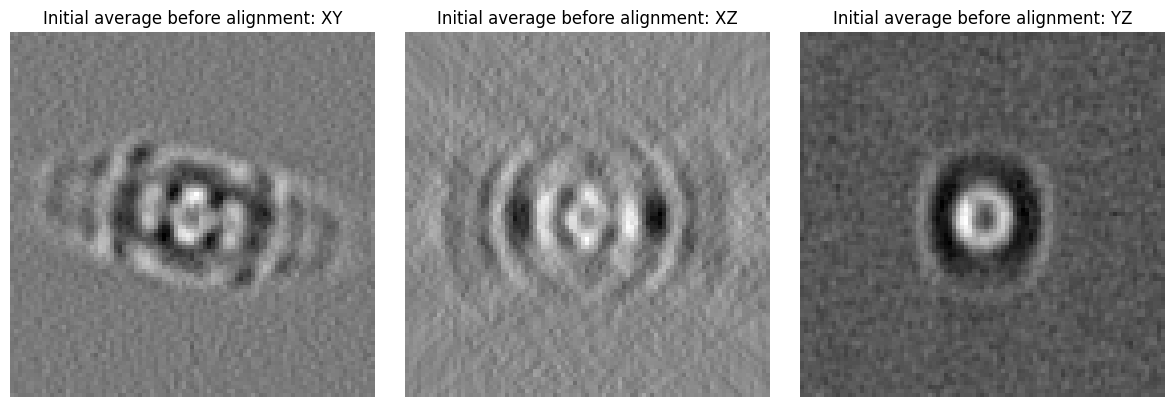

In [14]:
reference_round_00 = compute_streaming_average(cluster_paths, progress_every=progress_every)
reference_round_00_path = save_mrc(output_dir / "reference_round_00.mrc", reference_round_00)
print(f"Saved initial reference to: {reference_round_00_path}")
show_volume_slices(reference_round_00, "Initial average before alignment")
plt.show()


In [15]:
current_reference = reference_round_00.copy()
round_metrics = []
round_reference_paths = [reference_round_00_path]

for round_idx in range(1, n_rounds + 1):
    print(f"\nStarting round {round_idx}/{n_rounds}")
    round_start = time.perf_counter()

    reference_sampling_volume = prepare_sampling_volume(current_reference)
    xr, yr, zr = sample_volume_in_memory(
        reference_sampling_volume,
        threshold=threshold,
        num_points=num_points,
        random_seed=experiment_seed + 1000 * round_idx,
    )

    sum_rotated = np.zeros_like(current_reference, dtype=np.float64)
    count = 0
    subtomogram_rows = []

    for item_idx, path in enumerate(cluster_paths, start=1):
        subtomogram_start = time.perf_counter()
        volume = load_mrc(path, permissive=False)
        sampling_volume = prepare_sampling_volume(volume)
        x, y, z = sample_volume_in_memory(
            sampling_volume,
            threshold=threshold,
            num_points=num_points,
            random_seed=experiment_seed + round_idx + count,
        )

        quaternions, costs = SGD(
            x,
            y,
            z,
            xr,
            yr,
            zr,
            lr=lr,
            max_iter=max_iter,
            reg=reg,
            num_samples=num_samples,
            verbose=False,
            random_seed=experiment_seed + round_idx + count,
        )
        q_est = quaternions[-1]
        rotated_volume = rotate_volume_with_quaternion(volume, q_est)

        sum_rotated += rotated_volume
        count += 1
        runtime_s = time.perf_counter() - subtomogram_start
        subtomogram_rows.append({
            "round": round_idx,
            "subtomogram_id": int(path.stem),
            "file_name": path.name,
            "runtime_s": float(runtime_s),
            "final_cost": float(costs[-1]),
        })

        if progress_every and (item_idx % progress_every == 0 or item_idx == len(cluster_paths)):
            print(f"  Round {round_idx}: aligned {item_idx}/{len(cluster_paths)} subtomograms")

        del volume, sampling_volume, x, y, z, quaternions, costs, rotated_volume, q_est
        if cleanup_every and item_idx % cleanup_every == 0:
            gc.collect()

    next_reference = (sum_rotated / count).astype(np.float32)
    reference_path = save_mrc(output_dir / f"reference_round_{round_idx:02d}.mrc", next_reference)
    round_reference_paths.append(reference_path)

    round_df = pd.DataFrame(subtomogram_rows)
    change_row = reference_change_stats(current_reference, next_reference, round_idx)
    change_row.update({
        "n_subtomograms": int(count),
        "mean_runtime_s": float(round_df["runtime_s"].mean()),
        "mean_final_cost": float(round_df["final_cost"].mean()),
        "reference_path": str(reference_path),
        "round_runtime_s": float(time.perf_counter() - round_start),
    })
    round_metrics.append(change_row)

    current_reference = next_reference
    del reference_sampling_volume, xr, yr, zr, sum_rotated, round_df, subtomogram_rows, next_reference
    gc.collect()
    print(f"Completed round {round_idx}; saved reference to: {reference_path}")



Starting round 1/5
  Round 1: aligned 10/200 subtomograms
  Round 1: aligned 20/200 subtomograms
  Round 1: aligned 30/200 subtomograms
  Round 1: aligned 40/200 subtomograms
  Round 1: aligned 50/200 subtomograms
  Round 1: aligned 60/200 subtomograms
  Round 1: aligned 70/200 subtomograms
  Round 1: aligned 80/200 subtomograms
  Round 1: aligned 90/200 subtomograms
  Round 1: aligned 100/200 subtomograms
  Round 1: aligned 110/200 subtomograms
  Round 1: aligned 120/200 subtomograms
  Round 1: aligned 130/200 subtomograms
  Round 1: aligned 140/200 subtomograms
  Round 1: aligned 150/200 subtomograms
  Round 1: aligned 160/200 subtomograms
  Round 1: aligned 170/200 subtomograms
  Round 1: aligned 180/200 subtomograms
  Round 1: aligned 190/200 subtomograms
  Round 1: aligned 200/200 subtomograms
Completed round 1; saved reference to: iterative_alignment_outputs_cluster0/reference_round_01.mrc

Starting round 2/5
  Round 2: aligned 10/200 subtomograms
  Round 2: aligned 20/200 subto

In [16]:
round_metrics_df = pd.DataFrame(round_metrics, columns=[
    "round",
    "n_subtomograms",
    "mean_runtime_s",
    "mean_final_cost",
    "reference_l2_change",
    "reference_mean_abs_change",
    "reference_max_abs_change",
    "reference_path",
    "round_runtime_s",
])
round_metrics_path = output_dir / "round_metrics.csv"
round_metrics_df.to_csv(round_metrics_path, index=False)
print(f"Saved round metrics to: {round_metrics_path}")
round_metrics_df


Saved round metrics to: iterative_alignment_outputs_cluster0/round_metrics.csv


,round,n_subtomograms,mean_runtime_s,mean_final_cost,reference_l2_change,reference_mean_abs_change,reference_max_abs_change,reference_path,round_runtime_s
0,1,200,1.386690,949.612145,78.654884,0.071901,0.517157,iterative_alignment_outputs_cluster0/reference...,278.983871
1,2,200,1.373137,948.920458,80.687042,0.073842,0.472859,iterative_alignment_outputs_cluster0/reference...,276.385454
2,3,200,1.374336,912.853603,81.873177,0.074906,0.519463,iterative_alignment_outputs_cluster0/reference...,276.471195
3,4,200,1.360930,948.305300,80.728928,0.073852,0.450781,iterative_alignment_outputs_cluster0/reference...,273.775506
4,5,200,1.385094,942.603717,80.615189,0.073760,0.507870,iterative_alignment_outputs_cluster0/reference...,278.631459


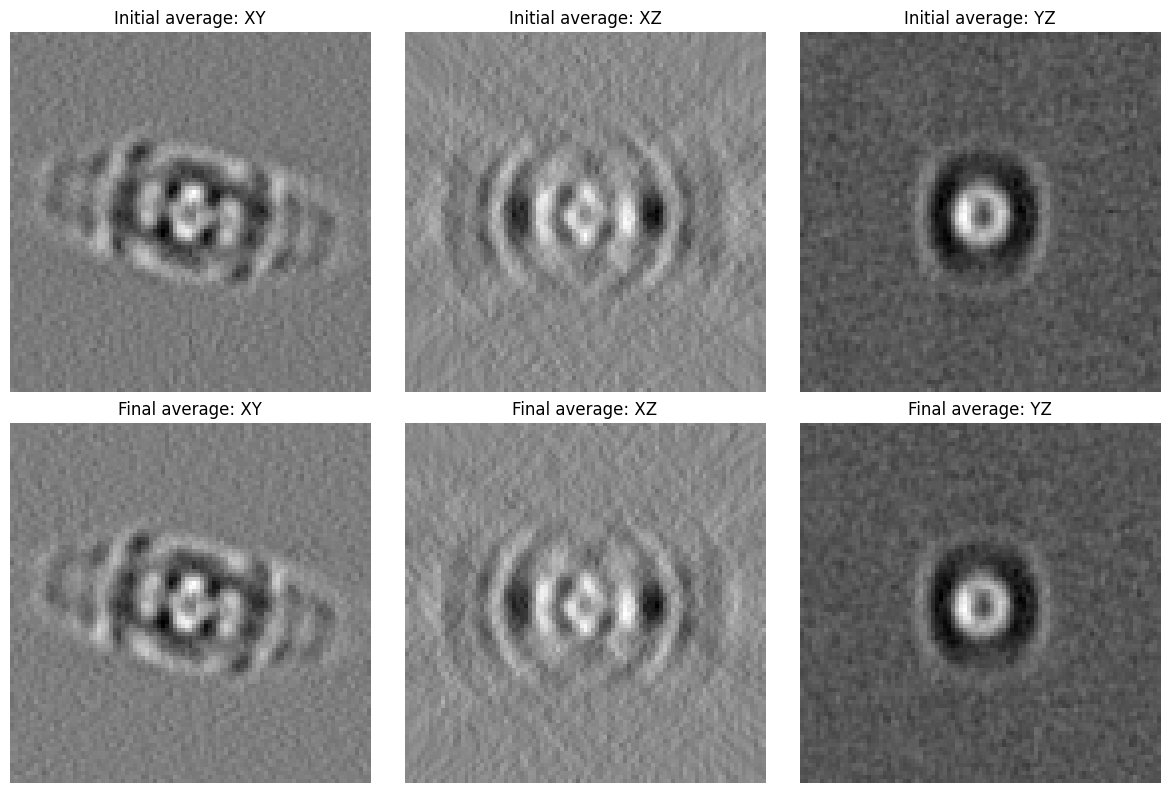

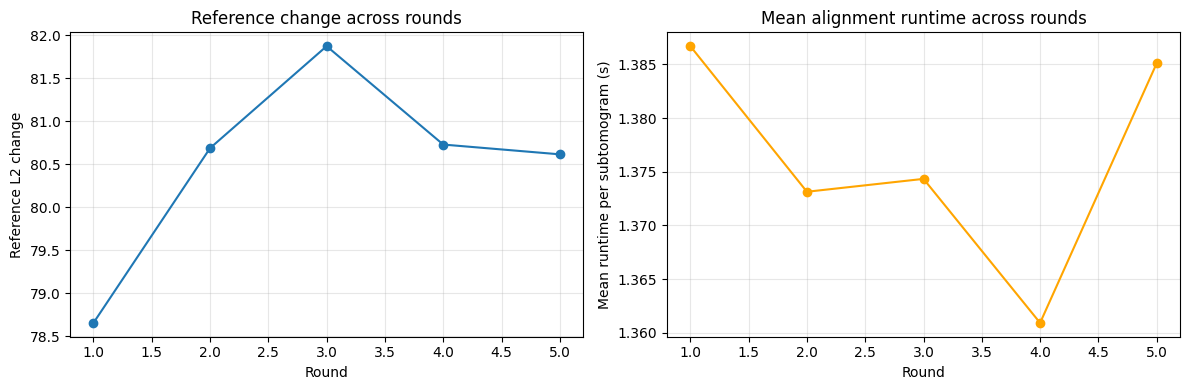

In [17]:
final_reference = current_reference

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
initial_mid_z = reference_round_00.shape[0] // 2
initial_mid_y = reference_round_00.shape[1] // 2
initial_mid_x = reference_round_00.shape[2] // 2
final_mid_z = final_reference.shape[0] // 2
final_mid_y = final_reference.shape[1] // 2
final_mid_x = final_reference.shape[2] // 2

axes[0, 0].imshow(reference_round_00[initial_mid_z, :, :], cmap="gray")
axes[0, 0].set_title("Initial average: XY")
axes[0, 1].imshow(reference_round_00[:, initial_mid_y, :], cmap="gray")
axes[0, 1].set_title("Initial average: XZ")
axes[0, 2].imshow(reference_round_00[:, :, initial_mid_x], cmap="gray")
axes[0, 2].set_title("Initial average: YZ")

axes[1, 0].imshow(final_reference[final_mid_z, :, :], cmap="gray")
axes[1, 0].set_title("Final average: XY")
axes[1, 1].imshow(final_reference[:, final_mid_y, :], cmap="gray")
axes[1, 1].set_title("Final average: XZ")
axes[1, 2].imshow(final_reference[:, :, final_mid_x], cmap="gray")
axes[1, 2].set_title("Final average: YZ")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(round_metrics_df["round"], round_metrics_df["reference_l2_change"], marker="o")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Reference L2 change")
axes[0].set_title("Reference change across rounds")
axes[0].grid(True, alpha=0.3)

axes[1].plot(round_metrics_df["round"], round_metrics_df["mean_runtime_s"], marker="o", color="orange")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Mean runtime per subtomogram (s)")
axes[1].set_title("Mean alignment runtime across rounds")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
